In [30]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import os


In [31]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS (Apple GPU)")
else:
    device = torch.device("cpu")
    print("Using CPU")


Using MPS (Apple GPU)


In [32]:
data_dir = "/Users/felixkevinsinght/TN/PlantDiseasesDataset/Apple"
train_dir = os.path.join(data_dir, "train")
valid_dir = os.path.join(data_dir, "valid")


In [33]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


In [34]:
train_data = datasets.ImageFolder(train_dir, transform=transform)
valid_data = datasets.ImageFolder(valid_dir, transform=transform)

print(f"Training classes: {train_data.classes}")


Training classes: ['Apple Black rot', 'Apple Healthy', 'Apple Scab', 'Cedar apple rust']


In [35]:
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32)


In [36]:
model = models.resnet18(pretrained=True)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(train_data.classes))
model = model.to(device)


/opt/anaconda3/envs/TN-agri/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [37]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [38]:
epochs = 10
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_accuracy = 100 * correct / total
    print(f"Epoch {epoch+1}/{epochs} - Loss: {running_loss:.4f} - Accuracy: {train_accuracy:.2f}%")


Epoch 1/10 - Loss: 48.3400 - Accuracy: 96.45%
Epoch 2/10 - Loss: 42.6401 - Accuracy: 96.67%
Epoch 3/10 - Loss: 13.4788 - Accuracy: 98.96%
Epoch 4/10 - Loss: 21.0947 - Accuracy: 98.38%
Epoch 5/10 - Loss: 8.7978 - Accuracy: 99.25%
Epoch 6/10 - Loss: 11.9348 - Accuracy: 99.01%
Epoch 7/10 - Loss: 7.4855 - Accuracy: 99.32%
Epoch 8/10 - Loss: 12.1162 - Accuracy: 99.06%
Epoch 9/10 - Loss: 10.4902 - Accuracy: 99.14%
Epoch 10/10 - Loss: 11.2317 - Accuracy: 99.06%


In [11]:
model_save_path = "/Users/felixkevinsinght/TN-agri/Plant-Disease-Detection-main/Flask Deployed App/plant_disease_model_1_latest.pt"
torch.save(model.state_dict(), model_save_path)
print(f"Model saved to {model_save_path}")


Model saved to /Users/felixkevinsinght/TN-agri/Plant-Disease-Detection-main/Flask Deployed App/plant_disease_modellatest.pt


In [12]:
from PIL import Image
import torchvision.transforms.functional as TF
import numpy as np


In [13]:
# Load the model architecture
model = models.resnet18(pretrained=False)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(train_data.classes))
model = model.to(device)

# Load saved weights
model_path = "/Users/felixkevinsinght/TN-agri/Plant-Disease-Detection-main/Flask Deployed App/plant_disease_model_1_latest.pt"
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()


/opt/anaconda3/envs/TN-agri/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [14]:
# Map index to class name
idx_to_class = {v: k for k, v in train_data.class_to_idx.items()}


In [15]:
def predict_image(image_path):
    image = Image.open(image_path).convert("RGB")
    image = image.resize((224, 224))
    input_tensor = TF.to_tensor(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        _, predicted = torch.max(output, 1)
        predicted_class = idx_to_class[predicted.item()]

    return predicted_class


In [18]:
test_image = "/Users/felixkevinsinght/TN/PlantDiseasesDataset/Apple/valid/Apple Healthy/AppleHealthy(3).jpg"  # Replace with your image
prediction = predict_image(test_image)
print("Predicted Class:", prediction)


Predicted Class: Cedar apple rust


In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [24]:
all_preds = []
all_probs = []
all_labels = []

model.eval()
with torch.no_grad():
    for inputs, labels in valid_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)

        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


<Figure size 800x600 with 0 Axes>

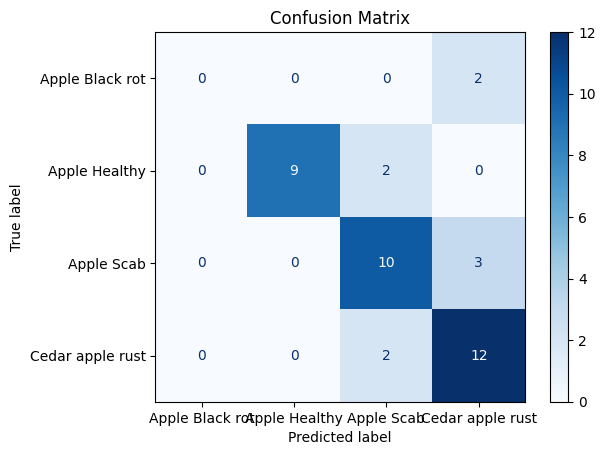

In [25]:
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=valid_data.classes)
plt.figure(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()


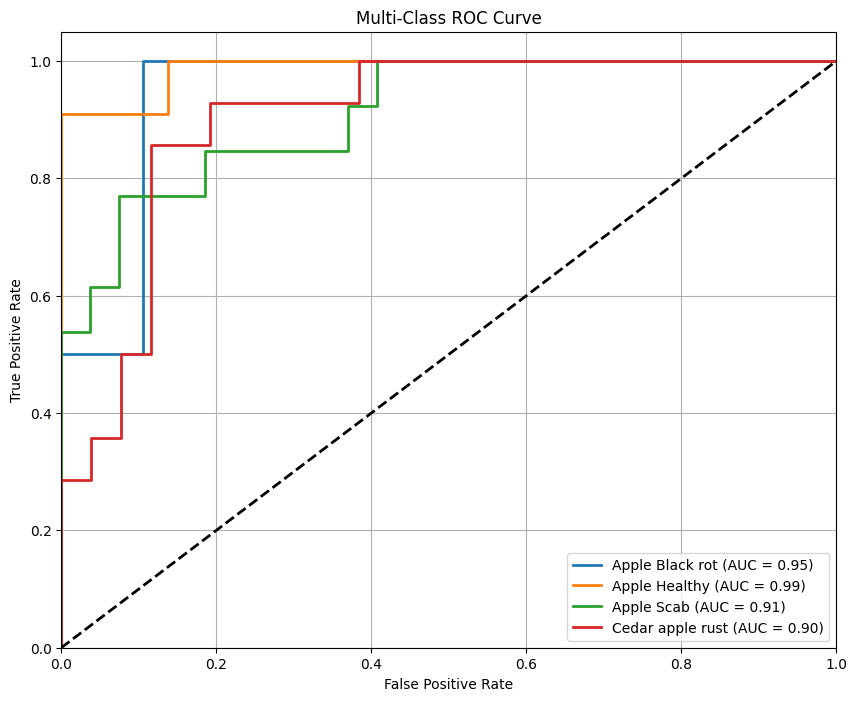

In [26]:
# One-hot encode the labels
n_classes = len(valid_data.classes)
y_true = label_binarize(all_labels, classes=range(n_classes))
y_score = np.array(all_probs)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 8))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], lw=2, label=f"{valid_data.classes[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
